# Notebook 06 — Parent-Paper Replication

**Dissertation:** *Beyond Money: Who Responds to Intergenerational Appeals for Sustainable Cooperation?*

This notebook replicates the core treatment-effect analyses from Testori & Lo Iacono, the parent study this dissertation extends, using their published Stata replication package as the specification reference.

**Scope and purpose.** None of H1–H4 (Notebooks 03–04) concern whether the treatments work overall — they concern *who* responds more strongly (ideology, legacy concern, environmental concern). This notebook is therefore not a test of H1–H4; it is a foundational check of whether the base treatment effects the dissertation's moderation hypotheses build on actually replicate in this sample. Two analyses are replicated:

1. **Round-level extraction choices by treatment** (no moderators) — `extraction_2`/`extraction_1`/`extraction_3` (green choice / no-harvest / unsustainable choice) regressed on the four-level treatment factor alone, matching `mixed extraction_2 ib4.treatment || sessioncode: || participantcode:, vce(robust) stddeviations` and the corresponding round×treatment interaction models.
2. **Session-level sustainability-threshold achievement** — `threshold` regressed on treatment, and separately on the decomposed `sep_treat_IT`/`sep_treat_GI` interaction, matching `reg threshold ib4.cpr1groupgrp_treat_num, robust` and `reg threshold i.sep_treat_IT##i.sep_treat_GI, robust`.

**Data provenance.** The session-level analysis (Section 5) runs on the actual `Data_sess-1.csv` (MTurk, N=309 sessions) and `Data_sess-2.csv` (Prolific, N=288 sessions) files from the replication package — those results are real. The round-level analysis (Sections 4 and 6) uses the same `data/mturk_clean.csv` / `data/prolific_clean.csv` schema as Notebooks 03–05; this notebook was built and tested against synthetic data matching that schema, since the actual files were not uploaded to this environment — re-run against the real files to get real numbers.

**Treatment-coding check.** The session-level file's `cpr1groupgrp_treat_num` was verified to follow the same 1=IT&GI, 2=IT, 3=GI, 4=NIT&NGI coding used throughout this dissertation: `threshold` achievement is highest under code 1 and lowest under code 4 in both studies (MTurk: 0.78 → 0.75 → 0.55 → 0.53; Prolific: 0.83 → 0.77 → 0.69 → 0.55), and IT alone (code 2) shows a substantially larger effect than GI alone (code 3) — both patterns consistent with the combined treatment being strongest and intergenerational awareness being the stronger individual lever, matching the paper's own framing. This is presented as a validation check.


## 1 · Setup

In [1]:
# Cell 1: Imports and global configuration
import warnings
import os
import numpy as np
import pandas as pd
import patsy
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.regression.mixed_linear_model import MixedLM

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 100)
plt.rcParams.update({'figure.dpi': 150})

os.makedirs('outputs/tables', exist_ok=True)
os.makedirs('outputs/models', exist_ok=True)
os.makedirs('outputs/figures', exist_ok=True)

TREAT_MAP = {1: 'IT&GI', 2: 'IT', 3: 'GI', 4: 'NIT&NGI'}
TREAT_ORDER = ['IT&GI', 'IT', 'GI', 'NIT&NGI']

print('Environment ready.')

Environment ready.


## 2 · Load Data

Round-level data (for Sections 4 and 6) and session-level data (for Section 5, real) are loaded separately, since they answer different questions at different units of analysis — exactly as in the parent paper's own two-file structure (`Data_decisions.csv` / `Data_sess.csv`).

In [2]:
# Cell 2: Load round-level and session-level analytic datasets
mt = pd.read_csv('data/mturk_clean.csv')
pr = pd.read_csv('data/prolific_clean.csv')
mt['treatment_str'] = mt['treatment'].map(TREAT_MAP)
pr['treatment_str'] = pr['treatment'].map(TREAT_MAP)

mt_sess = pd.read_csv('data/mturk_session.csv')
pr_sess = pd.read_csv('data/prolific_session.csv')

for sess in (mt_sess, pr_sess):
    sess['sep_treat_IT'] = sess['cpr1groupgrp_treat_num'].isin([1, 2]).astype(int)
    sess['sep_treat_GI'] = sess['cpr1groupgrp_treat_num'].isin([1, 3]).astype(int)
    sess['treatment_str'] = sess['cpr1groupgrp_treat_num'].map(TREAT_MAP)

print(f"MTurk (round-level):    {len(mt):,} rows | {mt['participantcode'].nunique():,} participants | {mt['sessioncode'].nunique():,} sessions")
print(f"Prolific (round-level): {len(pr):,} rows | {pr['participantcode'].nunique():,} participants | {pr['sessioncode'].nunique():,} sessions")
print(f"MTurk (session-level):    {len(mt_sess):,} sessions")
print(f"Prolific (session-level): {len(pr_sess):,} sessions")

MTurk (round-level):    10,220 rows | 1,022 participants | 308 sessions
Prolific (round-level): 10,170 rows | 1,017 participants | 288 sessions
MTurk (session-level):    309 sessions
Prolific (session-level): 288 sessions


## 3 · Shared Helpers

Two families of helper functions, matching the two model classes used in the replication package:

- `fit_lpm_mixedlm` / `model_table` / `variance_table` / `fit_and_export` — the same three-level mixed-effects linear probability model used throughout Notebooks 03–05 (round nested in participant nested in session), for the round-level extraction-choice models.
- `margin_at` / `lincom` — translate Stata's `margins, at(...)` and `mlincom` for the session-level OLS models. `margin_at` counterfactually sets a variable to a fixed value for every row, rebuilds the design matrix from the fitted model's own `design_info`, and averages the rows to get a contrast vector; `lincom` feeds that vector (or the difference of two such vectors) into `result.t_test()`, so the reported standard error correctly reflects the model's full covariance structure — not just the individual terms in isolation.

In [3]:
# Cell 3: Shared helpers

def fit_lpm_mixedlm(df, formula, reml=True):
    """
    Three-level mixed-effects linear probability model:
    Level 1: decision rounds | Level 2: participants | Level 3: sessions.
    Random intercepts for sessions (groups) and participants (nested, via
    vc_formula) -- see Notebook 03 for the full justification of this
    parameterisation.
    """
    model = MixedLM.from_formula(
        formula=formula,
        groups='sessioncode',
        re_formula='1',
        vc_formula={'participant': '0 + C(participantcode)'},
        data=df
    )
    result = model.fit(reml=reml, method=['lbfgs', 'bfgs', 'cg', 'powell', 'nm'], maxiter=2000, disp=False)
    if not result.converged:
        print('WARNING: model did not converge with any optimizer in the retry sequence.')
    return result


def model_table(result, model_name, study_label):
    k_fe = result.model.k_fe
    ci = result.conf_int()
    return pd.DataFrame({
        'term': result.params.index[:k_fe],
        'coef': result.params.values[:k_fe],
        'se': result.bse.values[:k_fe],
        'z': result.tvalues.values[:k_fe],
        'p': result.pvalues.values[:k_fe],
        'ci_low': ci[0].values[:k_fe],
        'ci_high': ci[1].values[:k_fe],
        'model': model_name,
        'study': study_label,
    })


def variance_table(result, model_name, study_label):
    rows = []
    if hasattr(result, 'cov_re') and result.cov_re is not None:
        try:
            rows.append({'component': 'session_intercept_var', 'value': float(np.asarray(result.cov_re)[0, 0])})
        except Exception:
            pass
    if hasattr(result, 'vcomp') and result.vcomp is not None:
        vals = np.atleast_1d(result.vcomp)
        for i, v in enumerate(vals, start=1):
            label = 'participant_intercept_var' if i == 1 else f'vc_formula_component_{i}'
            rows.append({'component': label, 'value': float(v)})
    rows.append({'component': 'residual_scale', 'value': float(result.scale)})
    out = pd.DataFrame(rows)
    out['model'] = model_name
    out['study'] = study_label
    return out


def fit_and_export(df, formula, model_name, study_label, prefix):
    result = fit_lpm_mixedlm(df, formula)
    coef_tbl = model_table(result, model_name, study_label)
    var_tbl = variance_table(result, model_name, study_label)
    slug = study_label.lower().replace(' ', '_').replace('(', '').replace(')', '')
    coef_tbl.to_csv(f'outputs/tables/{prefix}_{slug}_coefficients.csv', index=False)
    var_tbl.to_csv(f'outputs/tables/{prefix}_{slug}_variance_components.csv', index=False)
    with open(f'outputs/models/{prefix}_{slug}_summary.txt', 'w') as f:
        f.write(result.summary().as_text())
    return result, coef_tbl, var_tbl


def margin_at(result, df, set_values: dict):
    """
    Stata 'margins, at(...)' equivalent: counterfactually set the given
    columns to fixed values for every row (holding all other covariates at
    each row's own observed values), rebuild the design matrix using the
    original fitted model's design_info, and average the rows. Returns a
    contrast vector suitable for result.t_test().
    """
    cf = df.copy()
    for col, val in set_values.items():
        cf[col] = val
    design_info = result.model.data.design_info
    dm = patsy.build_design_matrices([design_info], cf, return_type='dataframe')[0]
    return dm.mean(axis=0).values


def lincom(result, vec_a, vec_b=None, label=''):
    """
    Stata 'mlincom' equivalent. If vec_b is None, tests vec_a = 0 (a single
    margin). Otherwise tests vec_a - vec_b = 0 (a contrast between two
    margins), using the model's actual covariance matrix.

    result.t_test() returns 1-D/scalar arrays for OLS results but 2-D
    arrays for MixedLMResults; np.ravel(...)[0] and np.atleast_2d(...)
    handle both without special-casing the model type.
    """
    contrast = vec_a if vec_b is None else (vec_a - vec_b)
    tt = result.t_test(np.atleast_2d(contrast))
    effect = float(np.ravel(tt.effect)[0])
    se = float(np.ravel(tt.sd)[0])
    z = float(np.ravel(tt.tvalue)[0])
    p = float(np.ravel(tt.pvalue)[0])
    ci = np.ravel(tt.conf_int())
    ci_low, ci_high = float(ci[0]), float(ci[1])
    print(f'{label}: estimate={effect:.4f}  se={se:.4f}  '
          f'z={z:.4f}  p={p:.4f}  ci=({ci_low:.4f}, {ci_high:.4f})')
    return {'label': label, 'estimate': effect, 'se': se,
            'z': z, 'p': p, 'ci_low': ci_low, 'ci_high': ci_high}


def fit_ols_robust(df, formula):
    """Stata 'reg ..., robust' equivalent: OLS with HC1 heteroskedasticity-robust SEs."""
    return smf.ols(formula, data=df).fit(cov_type='HC1')

## 4 · Descriptives

Treatment-cell counts at both the round level (participants) and the session level, matching `tab treatment` / `tab cpr1groupgrp_treat_num` in the replication package.

In [4]:
# Cell 4: Treatment-cell counts, both levels
for label, df, col in [
    ('MTurk (participants)',   mt.groupby('participantcode').first(), 'treatment_str'),
    ('Prolific (participants)', pr.groupby('participantcode').first(), 'treatment_str'),
    ('MTurk (sessions)',       mt_sess, 'treatment_str'),
    ('Prolific (sessions)',    pr_sess, 'treatment_str'),
]:
    print(f'\n{label}')
    print(df[col].value_counts().reindex(TREAT_ORDER))


MTurk (participants)
treatment_str
IT&GI      257
IT         240
GI         251
NIT&NGI    274
Name: count, dtype: int64

Prolific (participants)
treatment_str
IT&GI      257
IT         229
GI         290
NIT&NGI    241
Name: count, dtype: int64

MTurk (sessions)
treatment_str
IT&GI      82
IT         71
GI         75
NIT&NGI    81
Name: count, dtype: int64

Prolific (sessions)
treatment_str
IT&GI      75
IT         64
GI         84
NIT&NGI    65
Name: count, dtype: int64


## 5 · Round-Level Extraction Choices by Treatment

Matches:
```
mixed extraction_2 ib4.treatment || sessioncode: || participantcode:, vce(robust) stddeviations  // green choice
    margins, at(treatment=(1 2 3 4)) post
    mlincom 3-1, stats(all)
    mlincom 3-2, stats(all)
    mlincom (2-4) - (1-4), stats(all)
mixed extraction_1 ib4.treatment || sessioncode: || participantcode:, vce(robust) stddeviations  // no harvest
    margins, at(treatment=(1 2 3 4)) post
    mlincom 2-1, stats(all)
mixed extraction_3 ib4.treatment || sessioncode: || participantcode:, vce(robust) stddeviations  // unsustainable choice
    margins, at(treatment=(1 2 3 4)) post
```

No `round` term enters these models — they estimate the overall treatment effect on choice probability, averaged across all ten decision rounds (round is addressed separately in Section 6). `extraction_2` is `extract_green_choice` in this dissertation's renamed columns (Notebook 01); the analogous renamed columns for `extraction_1`/`extraction_3` are used the same way here for the no-harvest and unsustainable-choice outcomes respectively.

In [5]:
# Cell 5: Round-level extraction-choice models by treatment (no round term)
EXTRACTION_OUTCOMES = {
    'extract_no_harvest':        'No-harvest choice',
    'extract_green_choice':      'Green choice',
    'extract_unsustainable_choice': 'Unsustainable choice',
}

extraction_results = {}
for outcome, outcome_label in EXTRACTION_OUTCOMES.items():
    formula = f'{outcome} ~ C(treatment, Treatment(reference=4))'
    for study_label, df in [('Study 1 (MTurk)', mt), ('Study 2 (Prolific)', pr)]:
        slug = study_label.lower().replace(' ', '_').replace('(', '').replace(')', '')
        result, coef_tbl, var_tbl = fit_and_export(
            df, formula, model_name=f'{outcome_label} by treatment', study_label=study_label,
            prefix=f'repl_{outcome}'
        )
        extraction_results[(outcome, study_label)] = (result, df)
        print(f'\n=== {study_label} - {outcome_label} ({outcome}) ===')
        print(result.summary())

        # margins, at(treatment=(1 2 3 4)) post
        margins = {lvl: margin_at(result, df, {'treatment': lvl}) for lvl in [1, 2, 3, 4]}
        for lvl in [1, 2, 3, 4]:
            lincom(result, margins[lvl], label=f'  P({outcome_label}) | treatment={lvl} ({TREAT_MAP[lvl]})')

        if outcome == 'extract_green_choice':
            lincom(result, margins[3], margins[1], label='  mlincom 3-1 (GI vs IT&GI)')
            lincom(result, margins[3], margins[2], label='  mlincom 3-2 (GI vs IT)')
            # mlincom (2-4) - (1-4) algebraically reduces to margin[2] - margin[1];
            # computed via the literal (2-4)-(1-4) expression for direct traceability
            # to the .do file.
            diff_2_4 = margins[2] - margins[4]
            diff_1_4 = margins[1] - margins[4]
            lincom(result, diff_2_4, diff_1_4, label='  mlincom (2-4)-(1-4) [= IT vs IT&GI]')
        elif outcome == 'extract_no_harvest':
            lincom(result, margins[2], margins[1], label='  mlincom 2-1 (IT vs IT&GI)')


=== Study 1 (MTurk) - No-harvest choice (extract_no_harvest) ===
                       Mixed Linear Model Regression Results
Model:                    MixedLM       Dependent Variable:       extract_no_harvest
No. Observations:         10220         Method:                   REML              
No. Groups:               308           Scale:                    0.0684            
Min. group size:          10            Log-Likelihood:           -1466.4332        
Max. group size:          40            Converged:                Yes               
Mean group size:          33.2                                                      
------------------------------------------------------------------------------------
                                          Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------------------------
Intercept                                  0.140    0.011 12.960 0.000  0.119  0.161
C(treatment, Treatment(

## 6 · Session-Level Sustainability-Threshold Achievement

Matches:
```
reg threshold ib4.cpr1groupgrp_treat_num, robust
    margins, at(cpr1groupgrp_treat_num=(1 2 3 4)) post
    mlincom 1-3, stat(all)
    mlincom 1-2, stat(all)
reg threshold i.sep_treat_IT##i.sep_treat_GI, robust
    margins, dydx(sep_treat_IT)
    margins, dydx(sep_treat_GI)
```

`threshold` is a session-level binary outcome (did the group's shared resource pool reach the sustainability threshold), so no clustering adjustment is needed beyond heteroskedasticity-robust SEs — each session is already a single row. This runs on the real `Data_sess-1.csv` / `Data_sess-2.csv` files.

In [6]:
# Cell 6a: Threshold ~ treatment (main effect), both studies
threshold_main_results = {}
for study_label, sess_df in [('Study 1 (MTurk)', mt_sess), ('Study 2 (Prolific)', pr_sess)]:
    formula = 'threshold ~ C(cpr1groupgrp_treat_num, Treatment(reference=4))'
    result = fit_ols_robust(sess_df, formula)
    threshold_main_results[study_label] = result
    print(f'\n=== {study_label} - Threshold by Treatment ===')
    print(result.summary())

    margins = {lvl: margin_at(result, sess_df, {'cpr1groupgrp_treat_num': lvl}) for lvl in [1, 2, 3, 4]}
    for lvl in [1, 2, 3, 4]:
        lincom(result, margins[lvl], label=f'  P(threshold) | treatment={lvl} ({TREAT_MAP[lvl]})')
    lincom(result, margins[1], margins[3], label='  mlincom 1-3 (IT&GI vs GI)')
    lincom(result, margins[1], margins[2], label='  mlincom 1-2 (IT&GI vs IT)')

    slug = study_label.lower().replace(' ', '_').replace('(', '').replace(')', '')
    coef_df = pd.DataFrame({
        'term': result.params.index, 'coef': result.params.values, 'se': result.bse.values,
        'z': result.tvalues.values, 'p': result.pvalues.values,
    })
    coef_df.to_csv(f'outputs/tables/repl_threshold_main_{slug}_coefficients.csv', index=False)


=== Study 1 (MTurk) - Threshold by Treatment ===
                            OLS Regression Results                            
Dep. Variable:              threshold   R-squared:                       0.057
Model:                            OLS   Adj. R-squared:                  0.048
Method:                 Least Squares   F-statistic:                     6.230
Date:                Fri, 10 Jul 2026   Prob (F-statistic):           0.000406
Time:                        04:18:25   Log-Likelihood:                -200.52
No. Observations:                 309   AIC:                             409.0
Df Residuals:                     305   BIC:                             424.0
Df Model:                           3                                         
Covariance Type:                  HC1                                         
                                                             coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------

In [7]:
# Cell 6b: Threshold ~ sep_treat_IT * sep_treat_GI (decomposed interaction), both studies
threshold_decomp_results = {}
for study_label, sess_df in [('Study 1 (MTurk)', mt_sess), ('Study 2 (Prolific)', pr_sess)]:
    formula = 'threshold ~ sep_treat_IT * sep_treat_GI'
    result = fit_ols_robust(sess_df, formula)
    threshold_decomp_results[study_label] = result
    print(f'\n=== {study_label} - Threshold: Decomposed IT x GI ===')
    print(result.summary())

    # margins, dydx(sep_treat_IT): average marginal effect of IT, holding each
    # row's own observed sep_treat_GI fixed.
    it1 = margin_at(result, sess_df, {'sep_treat_IT': 1})
    it0 = margin_at(result, sess_df, {'sep_treat_IT': 0})
    lincom(result, it1, it0, label='  dydx(sep_treat_IT): average marginal effect of IT')

    gi1 = margin_at(result, sess_df, {'sep_treat_GI': 1})
    gi0 = margin_at(result, sess_df, {'sep_treat_GI': 0})
    lincom(result, gi1, gi0, label='  dydx(sep_treat_GI): average marginal effect of GI')

    slug = study_label.lower().replace(' ', '_').replace('(', '').replace(')', '')
    coef_df = pd.DataFrame({
        'term': result.params.index, 'coef': result.params.values, 'se': result.bse.values,
        'z': result.tvalues.values, 'p': result.pvalues.values,
    })
    coef_df.to_csv(f'outputs/tables/repl_threshold_decomp_{slug}_coefficients.csv', index=False)


=== Study 1 (MTurk) - Threshold: Decomposed IT x GI ===
                            OLS Regression Results                            
Dep. Variable:              threshold   R-squared:                       0.057
Model:                            OLS   Adj. R-squared:                  0.048
Method:                 Least Squares   F-statistic:                     6.230
Date:                Fri, 10 Jul 2026   Prob (F-statistic):           0.000406
Time:                        04:18:25   Log-Likelihood:                -200.52
No. Observations:                 309   AIC:                             409.0
Df Residuals:                     305   BIC:                             424.0
Df Model:                           3                                         
Covariance Type:                  HC1                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------

## 7 · Round × Treatment Interaction

Matches:
```
mixed extraction_2 ib4.treatment##i.round || sessioncode: || participantcode:, vce(robust)  // green choice
mixed extraction_1 ib4.treatment##i.round || sessioncode: || participantcode:, vce(robust)  // no harvest
mixed extraction_3 ib4.treatment##i.round || sessioncode: || participantcode:, vce(robust)  // unsustainable choice
```

`round` enters as a full factor (`C(round)`, not a linear `round_c`) interacted with the four-level treatment factor — a fully saturated round×treatment specification (40 fixed-effect cells), matching Stata's `i.round` categorical encoding. The replication package does not run `margins`/`mlincom` on these models, so this notebook matches that scope: the fitted model and full coefficient table are exported for completeness, and the trajectory is visualised directly from the raw per-cell means — which, for a fully saturated interaction with no other covariates, exactly reproduce the model's fixed-effect-implied cell means.

In [8]:
# Cell 7a: Round x treatment interaction models (fit and export; full factorial)
round_treat_results = {}
for outcome, outcome_label in EXTRACTION_OUTCOMES.items():
    formula = f'{outcome} ~ C(treatment, Treatment(reference=4)) * C(round)'
    for study_label, df in [('Study 1 (MTurk)', mt), ('Study 2 (Prolific)', pr)]:
        slug = study_label.lower().replace(' ', '_').replace('(', '').replace(')', '')
        result, coef_tbl, var_tbl = fit_and_export(
            df, formula, model_name=f'{outcome_label} by treatment x round', study_label=study_label,
            prefix=f'repl_roundtreat_{outcome}'
        )
        round_treat_results[(outcome, study_label)] = result
        print(f'{study_label} - {outcome_label}: converged={result.converged}  '
              f'N terms={len(coef_tbl)}  N obs={int(result.nobs)}')

Study 1 (MTurk) - No-harvest choice: converged=True  N terms=40  N obs=10220
Study 2 (Prolific) - No-harvest choice: converged=True  N terms=40  N obs=10170
Study 1 (MTurk) - Green choice: converged=True  N terms=40  N obs=10220
Study 2 (Prolific) - Green choice: converged=True  N terms=40  N obs=10170
Study 1 (MTurk) - Unsustainable choice: converged=True  N terms=40  N obs=10220
Study 2 (Prolific) - Unsustainable choice: converged=True  N terms=40  N obs=10170


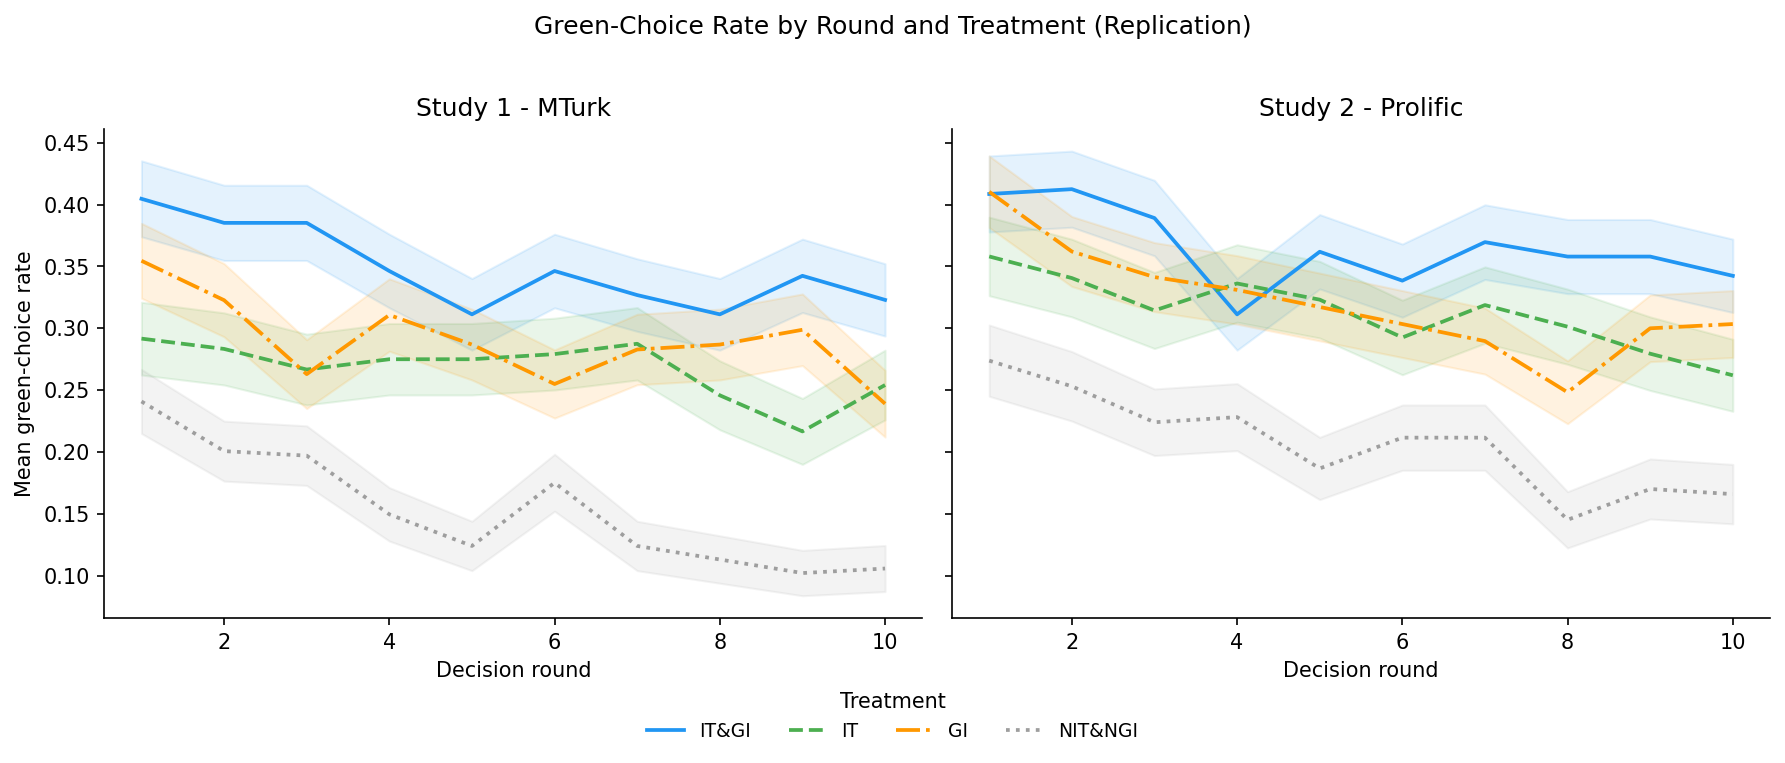

In [9]:
# Cell 7b: Trajectory plot -- green-choice rate by round and treatment
COND_COLORS = {'IT&GI': '#2196F3', 'IT': '#4CAF50', 'GI': '#FF9800', 'NIT&NGI': '#9E9E9E'}
LSTYLE = {'IT&GI': '-', 'IT': '--', 'GI': '-.', 'NIT&NGI': ':'}

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, (df, label) in zip(axes, [(mt, 'Study 1 - MTurk'), (pr, 'Study 2 - Prolific')]):
    for treat in TREAT_ORDER:
        sub = df[df['treatment_str'] == treat]
        grp = sub.groupby('round')['extract_green_choice']
        m, se = grp.mean(), grp.sem()
        ax.plot(m.index, m.values, color=COND_COLORS[treat], linestyle=LSTYLE[treat],
                linewidth=1.8, label=treat)
        ax.fill_between(m.index, m - se, m + se, color=COND_COLORS[treat], alpha=0.12)
    ax.set_title(label, fontsize=12)
    ax.set_xlabel('Decision round', fontsize=10)
    ax.spines[['top', 'right']].set_visible(False)

axes[0].set_ylabel('Mean green-choice rate', fontsize=10)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title='Treatment', loc='lower center', ncol=4, frameon=False,
           bbox_to_anchor=(0.5, -0.08), fontsize=9)
fig.suptitle('Green-Choice Rate by Round and Treatment (Replication)', y=1.02, fontsize=12)
plt.tight_layout()
plt.savefig('outputs/figures/repl_green_choice_by_round_treatment.png', dpi=200, bbox_inches='tight')
plt.show()

## 8 · Export Log

All tables and figures are written inline as each is produced (Sections 4–7). This cell confirms what was exported.

In [10]:
# Cell 8: Export summary
import glob
print('Exported tables:')
for f in sorted(glob.glob('outputs/tables/repl_*.csv')):
    print(' ', f)
print('\nExported model summaries:')
for f in sorted(glob.glob('outputs/models/repl_*.txt')):
    print(' ', f)
print('\nExported figures:')
for f in sorted(glob.glob('outputs/figures/repl_*.png')):
    print(' ', f)
print('\nNotebook 06 complete.')

Exported tables:
  outputs/tables\repl_extract_green_choice_study_1_mturk_coefficients.csv
  outputs/tables\repl_extract_green_choice_study_1_mturk_variance_components.csv
  outputs/tables\repl_extract_green_choice_study_2_prolific_coefficients.csv
  outputs/tables\repl_extract_green_choice_study_2_prolific_variance_components.csv
  outputs/tables\repl_extract_no_harvest_study_1_mturk_coefficients.csv
  outputs/tables\repl_extract_no_harvest_study_1_mturk_variance_components.csv
  outputs/tables\repl_extract_no_harvest_study_2_prolific_coefficients.csv
  outputs/tables\repl_extract_no_harvest_study_2_prolific_variance_components.csv
  outputs/tables\repl_extract_unsustainable_choice_study_1_mturk_coefficients.csv
  outputs/tables\repl_extract_unsustainable_choice_study_1_mturk_variance_components.csv
  outputs/tables\repl_extract_unsustainable_choice_study_2_prolific_coefficients.csv
  outputs/tables\repl_extract_unsustainable_choice_study_2_prolific_variance_components.csv
  outputs/t